In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

# check pytorch version

torch.__version__

# create device agnostic code.
device = "cuda" if torch.cuda.is_available() else "cpu"
device

# create dummy dataset for Model to learn using linear regression formula
# y = weight * X + bias
# set weight and bias to what ever values you want

# Build a model that would estimate weight and bias values
weight = 0.7
bias = 0.3

# create range values
start = 0
end = 1
step = 0.02

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1) # X is matrix
y = weight * X + bias

X[:10], y[:10]

# Split the data into training and testing dataset
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

# Plot the data
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plot training data and test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot testing data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  # Are there predictions ?
  if predictions is not None:
    # Plot predictions in red
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # show the legends
  plt.legend(prop={"size": 14})

plot_predictions(X_train, y_train, X_test, y_test)



In [ ]:
# Building a pytorch linear model by subclassing nn.Module

class LinerRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()

    # Initialize layers that have parameter inbuilt in those layers , use torch liner layer
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# Set the manual seeds
torch.manual_seed(42)

# Create an instance of the model
model_1 = LinerRegressionModelV2()

model_1, model_1.state_dict()



(LinerRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
# Set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

In [ ]:
from numpy import test
# Train the model

# For training we need :
"""
1. Loss function - tell us how far off our prediction is from the ground truth
2. Optimizer - optimizes the parameter of the model
3. Training loop
4. Testing loop
"""

# Setup loss function
loss_fn = nn.L1Loss() # same as MAE

# Setup Optimizer
optimizer = torch.optim.SGD(lr=0.01, params=model_1.parameters())

# let's write a training loop
torch.manual_seed(42)

epoch = 200

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epoch):
  model_1.train()

  # 1. Forward pass
  y_pred = model_1(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3. Optimzer zero grad
  optimizer.zero_grad()

  # 4. Loss backward perfrom back propagation
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred, y_test)

  # Print out what's happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")



Epoch: 0 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 10 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 20 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 30 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 40 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 50 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 60 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 70 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 80 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 90 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 100 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 110 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 120 | Loss: 0.0012645035749301314 | Test Loss: 0.013801801018416882
Epoch: 130 | Loss: 0.001264503574930

In [ ]:
model_1.state_dict()


OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [ ]:
# Making and evaluating predictions
# turn the model into eval mode

model_1.eval()

# make predictions on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)

y_preds


tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

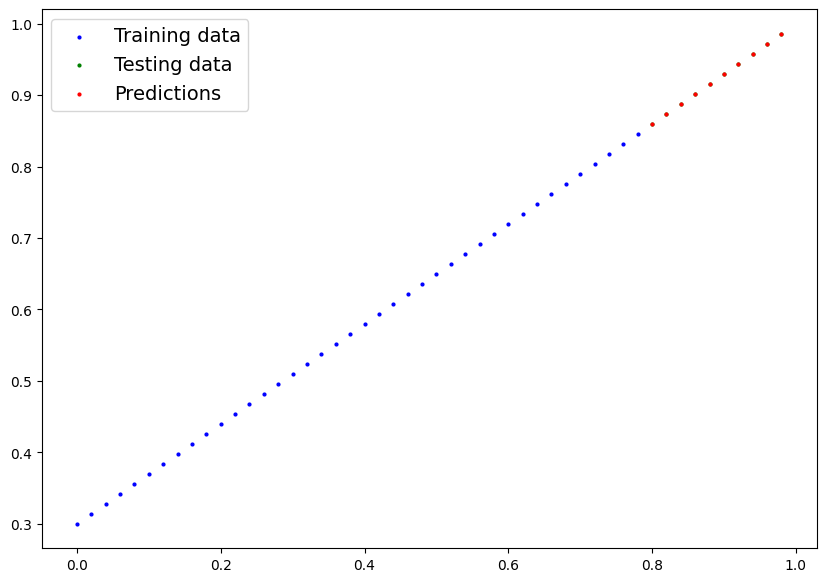

In [ ]:
# Check out model predictions visually

plot_predictions(predictions=y_preds.cpu())


In [ ]:
# Saving and loading the model

from pathlib import Path
# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "putting_everything_together.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/putting_everything_together.pth


In [ ]:
from pickle import load
# Load a pytorch model

# Create a new instance
loaded_model_1 = LinerRegressionModelV2()

# Load the saved model_1 state_dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put the loaded model to device
loaded_model_1.to(device)


LinerRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(loaded_model_1.parameters()).device

device(type='cuda', index=0)

In [ ]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [ ]:
from IPython.utils.tempdir import TemporaryWorkingDirectory
# Evaluated loaded model

loaded_model_1.eval()
with torch.inference_mode():
  loaded_model_1_preds = loaded_model_1(X_test)

y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')